# Phase envelopes and performance characteristics

This notebook traces a methane/n-butane bubble/dew envelope, validates every
point against a frozen ThermoPack 2.2 reference, and contrasts vectorized
cubic-root throughput with scalar evaluation. Timings are illustrative, not
portable benchmark records; hardware and PyTorch version are printed.

Sources:

- saturation-point and phase-envelope formulation: Michelsen and Mollerup,
  *Thermodynamic Models*, 2nd ed. (2007), chapter 12,
  <https://books.google.com/books?id=qjmeOgAACAAJ>
- Peng–Robinson equation: <https://doi.org/10.1021/i160057a011>
- external reference implementation:
  <https://github.com/thermotools/thermopack/releases>

In [1]:
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from torch_flash import component_set, peng_robinson_1978, phase_envelope

torch.set_default_dtype(torch.float64)
repo_root = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "pyproject.toml").is_file()
)
print(
    {
        "platform": platform.platform(),
        "torch": torch.__version__,
        "threads": torch.get_num_threads(),
        "CUDA available": torch.cuda.is_available(),
    }
)

{'platform': 'macOS-26.5.2-arm64-arm-64bit', 'torch': '2.12.1', 'threads': 10, 'CUDA available': False}


## Isopleth bubble and dew branches

In [2]:
components = component_set(("methane", "n_butane"))
model = peng_robinson_1978(components)
composition = torch.tensor([0.5, 0.5])
temperatures = torch.linspace(235.0, 300.0, 8)
envelope = phase_envelope(model, temperatures, composition)

records = []
for kind, points in envelope.items():
    for point in points:
        records.append(
            {
                "kind": kind,
                "T [K]": point.temperature.item(),
                "P [MPa]": point.pressure.item() / 1.0e6,
                "converged": point.converged,
                "residual": point.residual_norm.item(),
            }
        )
envelope_frame = pd.DataFrame(records)
envelope_frame

,kind,T [K],P [MPa],converged,residual
0,bubble,235.000000,5.646754,True,2.131628e-14
1,bubble,244.285714,6.360747,True,4.307665e-14
2,bubble,253.571429,7.048958,True,1.341149e-13
3,bubble,262.857143,7.700136,True,4.680700e-13
4,bubble,272.142857,8.305606,True,1.894929e-12
5,bubble,281.428571,8.858619,True,8.802292e-12
6,bubble,290.714286,9.353672,True,4.661516e-11
7,bubble,300.000000,9.785849,True,2.751792e-10
8,dew,235.000000,0.037899,True,3.104184e-12
9,dew,244.285714,0.060789,True,6.437784e-11


In [3]:
thermopack_wide = pd.read_csv(
    repo_root / "tests" / "data" / "thermopack_pr_phase_envelope.csv"
)
thermopack_records = []
for row in thermopack_wide.itertuples(index=False):
    thermopack_records.extend(
        (
            {
                "kind": "bubble",
                "T [K]": row.temperature_K,
                "P ThermoPack [MPa]": row.bubble_pressure_Pa / 1.0e6,
                "incipient methane ThermoPack": row.bubble_y_methane,
            },
            {
                "kind": "dew",
                "T [K]": row.temperature_K,
                "P ThermoPack [MPa]": row.dew_pressure_Pa / 1.0e6,
                "incipient methane ThermoPack": row.dew_x_methane,
            },
        )
    )
thermopack_frame = pd.DataFrame(thermopack_records)
comparison = pd.merge_asof(
    envelope_frame.sort_values(["T [K]", "kind"]),
    thermopack_frame.sort_values(["T [K]", "kind"]),
    on="T [K]",
    by="kind",
    direction="nearest",
    tolerance=1.0e-6,
)
if comparison["P ThermoPack [MPa]"].isna().any():
    raise RuntimeError("a torch-flash envelope point has no ThermoPack match")
comparison["pressure relative difference [%]"] = (
    100.0
    * (comparison["P [MPa]"] - comparison["P ThermoPack [MPa]"])
    / comparison["P ThermoPack [MPa]"]
)
comparison

,kind,T [K],P [MPa],converged,residual,P ThermoPack [MPa],incipient methane ThermoPack,pressure relative difference [%]
0,bubble,235.000000,5.646754,True,2.131628e-14,5.918844,0.985209,-4.597006
1,dew,235.000000,0.037899,True,3.104184e-12,0.039258,0.001958,-3.461475
2,bubble,244.285714,6.360747,True,4.307665e-14,6.648380,0.978131,-4.326354
3,dew,244.285714,0.060789,True,6.437784e-11,0.062740,0.002815,-3.110091
4,bubble,253.571429,7.048958,True,1.341149e-13,7.346444,0.969117,-4.049389
5,dew,253.571429,0.093893,True,6.681833e-11,0.096594,0.003949,-2.796099
6,bubble,262.857143,7.700136,True,4.680700e-13,8.002016,0.957989,-3.772546
7,dew,262.857143,0.140323,True,7.463163e-11,0.143943,0.005426,-2.515271
8,bubble,272.142857,8.305606,True,1.894929e-12,8.606878,0.944550,-3.500360
9,dew,272.142857,0.203751,True,9.096746e-11,0.208471,0.007324,-2.263884


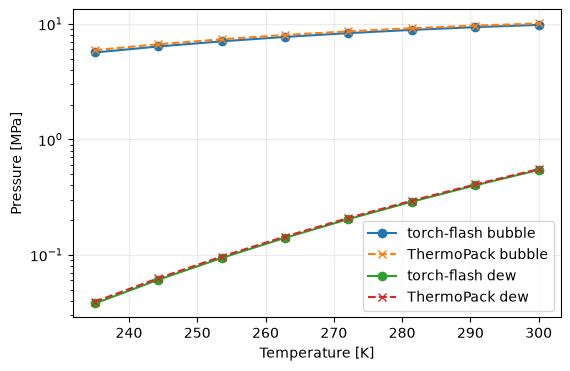

In [4]:
fig, ax = plt.subplots(figsize=(6.3, 4.0))
for kind, group in envelope_frame.groupby("kind"):
    reference = thermopack_frame.query("kind == @kind")
    ax.plot(
        group["T [K]"],
        group["P [MPa]"],
        "o-",
        label=f"torch-flash {kind}",
    )
    ax.plot(
        reference["T [K]"],
        reference["P ThermoPack [MPa]"],
        "x--",
        label=f"ThermoPack {kind}",
    )
ax.set(xlabel="Temperature [K]", ylabel="Pressure [MPa]")
ax.set_yscale("log")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

## Parity and residual diagnostics

The two implementations use independent pure-component databases. The
resulting smooth, systematic offset is therefore assessed with an
engineering tolerance instead of being presented as bitwise agreement.

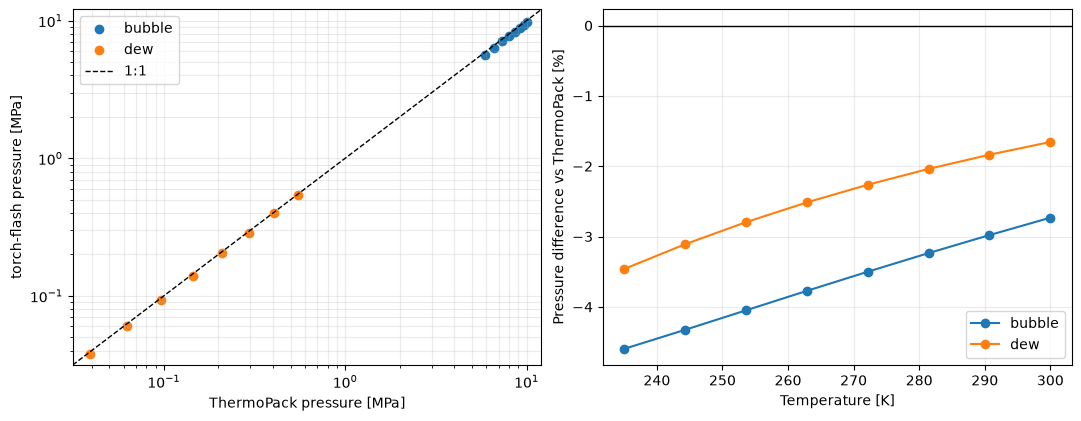

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.7, 4.1), constrained_layout=True)
for kind, group in comparison.groupby("kind"):
    axes[0].scatter(
        group["P ThermoPack [MPa]"],
        group["P [MPa]"],
        label=kind,
    )
limits = [
    comparison["P ThermoPack [MPa]"].min() * 0.8,
    comparison["P ThermoPack [MPa]"].max() * 1.2,
]
axes[0].plot(limits, limits, "k--", linewidth=1, label="1:1")
axes[0].set(
    xscale="log",
    yscale="log",
    xlim=limits,
    ylim=limits,
    xlabel="ThermoPack pressure [MPa]",
    ylabel="torch-flash pressure [MPa]",
)
axes[0].grid(alpha=0.25, which="both")
axes[0].legend()

for kind, group in comparison.groupby("kind"):
    axes[1].plot(
        group["T [K]"],
        group["pressure relative difference [%]"],
        "o-",
        label=kind,
    )
axes[1].axhline(0.0, color="k", linewidth=1)
axes[1].set(
    xlabel="Temperature [K]",
    ylabel="Pressure difference vs ThermoPack [%]",
)
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.show()

In [6]:
pd.Series(
    {
        "points compared": len(comparison),
        "all torch-flash points converged": comparison.converged.all(),
        "max nonlinear residual": comparison.residual.max(),
        "max |pressure difference| [%]": (
            comparison["pressure relative difference [%]"].abs().max()
        ),
    }
)

points compared                           16
all torch-flash points converged        True
max nonlinear residual                   0.0
max |pressure difference| [%]       4.597006
dtype: object

This is a temperature-grid continuation, not a critical-point arclength
continuation algorithm. Near branch turning points, a production envelope
tracer should switch parameterization and monitor root coalescence.

## Batched cubic-root throughput

In [7]:
batch_size = 20_000
t_batch = torch.linspace(240.0, 380.0, batch_size)
p_batch = torch.linspace(1.0e5, 8.0e6, batch_size)
x0 = torch.linspace(0.05, 0.95, batch_size)
x_batch = torch.stack((x0, 1.0 - x0), dim=-1)

started = time.perf_counter()
z_batch = model.z_factors(t_batch, p_batch, x_batch)
batch_seconds = time.perf_counter() - started

scalar_count = 500
started = time.perf_counter()
for index in range(scalar_count):
    model.z_factors(t_batch[index], p_batch[index], x_batch[index])
scalar_seconds = time.perf_counter() - started

pd.Series(
    {
        "batch states": batch_size,
        "batch wall time [s]": batch_seconds,
        "batch states/s": batch_size / batch_seconds,
        "scalar-loop states": scalar_count,
        "scalar-loop states/s": scalar_count / scalar_seconds,
        "vectorization speed ratio": (
            (batch_size / batch_seconds) / (scalar_count / scalar_seconds)
        ),
        "all finite": torch.isfinite(z_batch).all().item(),
    }
)

batch states                          20000
batch wall time [s]                0.003933
batch states/s               5085554.353327
scalar-loop states                      500
scalar-loop states/s            5672.871095
vectorization speed ratio        896.469225
all finite                             True
dtype: object

In [8]:
if torch.cuda.is_available():
    cuda_components = components.to(device="cuda")
    cuda_model = peng_robinson_1978(cuda_components)
    t_cuda, p_cuda, x_cuda = t_batch.cuda(), p_batch.cuda(), x_batch.cuda()
    for _ in range(3):
        cuda_model.z_factors(t_cuda, p_cuda, x_cuda)
    torch.cuda.synchronize()
    started = time.perf_counter()
    cuda_model.z_factors(t_cuda, p_cuda, x_cuda)
    torch.cuda.synchronize()
    print({"CUDA batch states/s": batch_size / (time.perf_counter() - started)})
else:
    print("CUDA comparison skipped on this host.")

CUDA comparison skipped on this host.


Reactive-transport coupling benefits most from batching many independent
cells. Complete equilibrium flashes contain iterative control flow and will
show smaller GPU gains than this algebraic cubic-root kernel; representative
simulator-scale profiling is still required.